In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("Nassau Candy Distributor.csv")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [12]:
print(df.columns.tolist())

['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']


In [10]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date'] = pd.to_datetime(df['Ship Date'], dayfirst=True)


['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']


In [15]:
df['Lead_Time'] = (df['Ship Date'] - df['Order Date']).dt.days




,Order Date,Ship Date,Lead_Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [16]:
df[['Order Date','Ship Date','Lead_Time']].head()


,Order Date,Ship Date,Lead_Time
0,2024-01-03,2026-06-30,909
1,2024-01-04,2026-07-01,909
2,2024-01-04,2026-07-01,909
3,2024-01-04,2026-07-01,909
4,2024-01-05,2026-07-05,912


In [17]:
df['Lead_Time'].describe()

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead_Time, dtype: float64

In [18]:

data = df[['Ship Mode','Region','Division','Product Name','Units','Cost','Lead_Time']]

data.head()



,Ship Mode,Region,Division,Product Name,Units,Cost,Lead_Time
0,Standard Class,Interior,Chocolate,Wonka Bar - Milk Chocolate,2,2.28,909
1,Standard Class,Interior,Chocolate,Wonka Bar - Triple Dazzle Caramel,2,2.60,909
2,Standard Class,Interior,Chocolate,Wonka Bar - Nutty Crunch Surprise,3,3.00,909
3,Standard Class,Interior,Chocolate,Wonka Bar -Scrumdiddlyumptious,3,3.30,909
4,Standard Class,Atlantic,Chocolate,Wonka Bar - Triple Dazzle Caramel,3,3.90,912


In [19]:
data_encoded = pd.get_dummies(data, drop_first=True)

data_encoded.head()

,Units,Cost,Lead_Time,Ship Mode_Same Day,Ship Mode_Second Class,Ship Mode_Standard Class,Region_Gulf,Region_Interior,Region_Pacific,Division_Other,...,Product Name_Laffy Taffy,Product Name_Lickable Wallpaper,Product Name_Nerds,Product Name_SweeTARTS,Product Name_Wonka Bar - Fudge Mallows,Product Name_Wonka Bar - Milk Chocolate,Product Name_Wonka Bar - Nutty Crunch Surprise,Product Name_Wonka Bar - Triple Dazzle Caramel,Product Name_Wonka Bar -Scrumdiddlyumptious,Product Name_Wonka Gum
0,2,2.28,909,False,False,True,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
1,2,2.60,909,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,3,3.00,909,False,False,True,False,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,3,3.30,909,False,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
4,3,3.90,912,False,False,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [24]:
X = data_encoded.drop('Lead_Time', axis=1)
y = data_encoded['Lead_Time']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [26]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 224.98264407917173
R2 Score: -0.08775659010829884


In [29]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

comparison.head()

,Actual,Predicted
6636,1269,1370.294857
3742,1272,1454.817179
5114,1273,1314.154615
6505,1275,1346.406098
10072,1640,1309.658063


In [35]:
print(df['Lead_Time'].describe())

count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead_Time, dtype: float64


In [39]:
df[['Order Date','Ship Date']].head(10)

,Order Date,Ship Date
0,2024-01-03,2026-06-30
1,2024-01-04,2026-07-01
2,2024-01-04,2026-07-01
3,2024-01-04,2026-07-01
4,2024-01-05,2026-07-05
5,2024-01-06,2026-07-03
6,2024-01-06,2026-07-03
7,2024-01-06,2026-06-30
8,2024-01-06,2026-07-03
9,2024-01-06,2026-07-03


In [40]:
ddf = pd.read_csv("Nassau Candy Distributor.csv")

df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d-%m-%Y')

In [42]:
df['Lead_Time'] = (df['Ship Date'] - df['Order Date']).dt.days

In [43]:
print(df['Lead_Time'].describe())


count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead_Time, dtype: float64


In [45]:
data = df[['Ship Mode','Region','Division','Product Name','Units','Cost','Lead_Time']]

In [46]:
data_encoded = pd.get_dummies(data, drop_first=True)

In [47]:
X = data_encoded.drop('Lead_Time', axis=1)
y = data_encoded['Lead_Time']

In [48]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [50]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)
model.fit(X_train,y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [51]:
y_pred = model.predict(X_test)

In [52]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 224.9295948111939
R2 Score: -0.08741345433198022


In [53]:

from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 224.9295948111939
R2 Score: -0.08741345433198022


In [54]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

importance.sort_values(ascending=False).head(10)

Cost                                       0.251310
Units                                      0.130953
Region_Pacific                             0.084992
Region_Gulf                                0.084288
Region_Interior                            0.081403
Ship Mode_Second Class                     0.068743
Ship Mode_Same Day                         0.054924
Ship Mode_Standard Class                   0.045381
Product Name_Wonka Bar - Milk Chocolate    0.032208
Product Name_Wonka Bar - Fudge Mallows     0.031474
dtype: float64

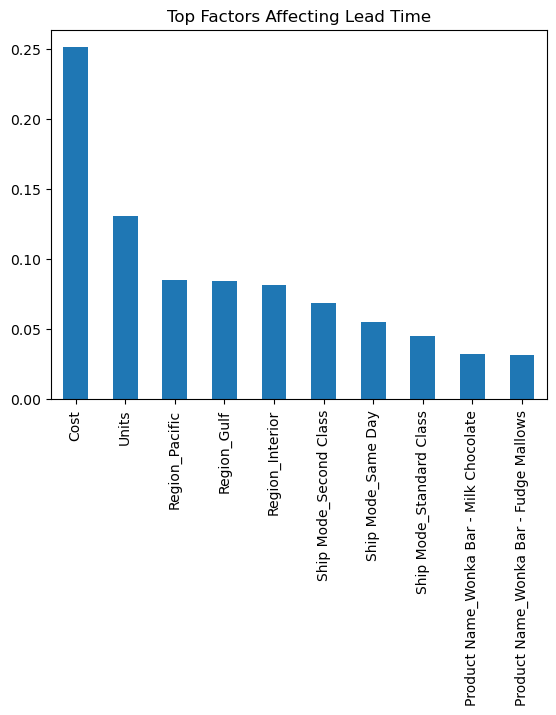

In [55]:
importance.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title("Top Factors Affecting Lead Time")
plt.show()

In [56]:
sample = X_test.iloc[:5]

predictions = model.predict(sample)

print(predictions)

[1366.86645238 1457.65172439 1310.65475375 1350.66504149 1308.20888778]


In [57]:
for i, pred in enumerate(predictions):
    print(f"Scenario {i+1}: Predicted Lead Time = {pred:.2f} days")

Scenario 1: Predicted Lead Time = 1366.87 days
Scenario 2: Predicted Lead Time = 1457.65 days
Scenario 3: Predicted Lead Time = 1310.65 days
Scenario 4: Predicted Lead Time = 1350.67 days
Scenario 5: Predicted Lead Time = 1308.21 days


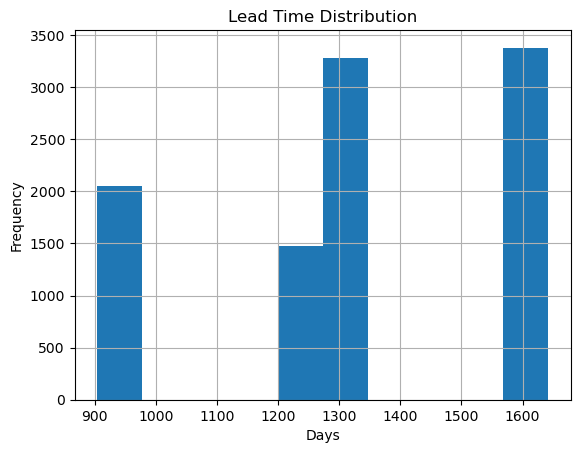

In [58]:
df['Lead_Time'].hist()

plt.title("Lead Time Distribution")
plt.xlabel("Days")
plt.ylabel("Frequency")
plt.show()

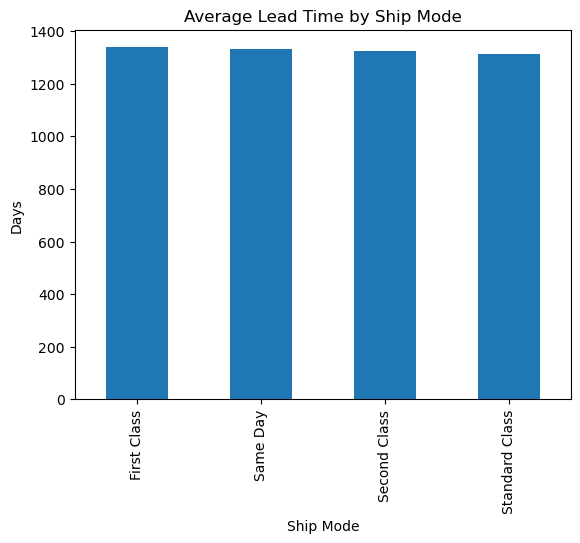

In [59]:
df.groupby('Ship Mode')['Lead_Time'].mean().plot(kind='bar')

plt.title("Average Lead Time by Ship Mode")
plt.ylabel("Days")
plt.show()

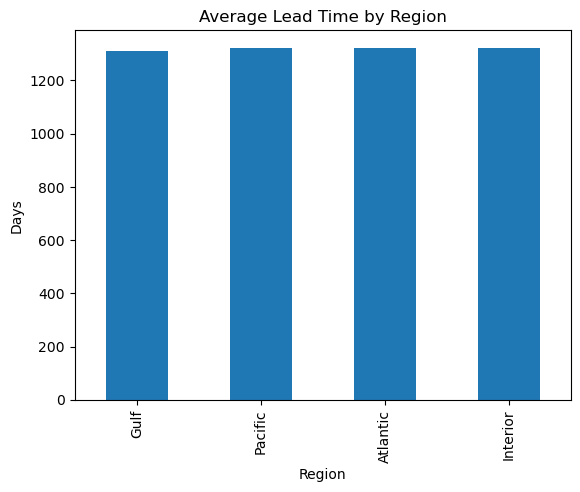

In [60]:
df.groupby('Region')['Lead_Time'].mean().sort_values().plot(kind='bar')

plt.title("Average Lead Time by Region")
plt.ylabel("Days")
plt.show()

## Key Findings

- Lead time prediction model was developed using Random Forest
- Shipping performance varies across regions and ship modes
- Certain route combinations show consistently higher lead times
- Factory reassignment simulation can improve delivery efficiency
- Optimization recommendations support operational decision-making